In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import sacrebleu
from bert_score import score as bertscore_score
from datasets import Dataset
from peft import PeftModel
from rouge_score import rouge_scorer
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

In [ ]:
MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.3"
ADAPTER_PATH = Path("agents/models/trained/model_mistral_solver_fast/lora_adapter")
DATA_PATH = "master_incident_dataset.parquet"
OUT_DIR = Path("agents/models/trained/model_mistral_solver/eval")
MAX_SEQ_LEN = 1024
TEST_SIZE = 0.2
SPLIT_SEED = 42
N_EVAL = None  # set to an int like 200 for faster testing, or keep None for full test set

SYSTEM_PROMPT = (
    "You are a Kubernetes Site Reliability Engineering (SRE) agent. "
    "Given raw observability evidence from a Kubernetes incident, provide:\n"
    "1. A root cause diagnosis explaining what went wrong and why.\n"
    "2. A step-by-step fix plan to resolve the incident.\n"
    "3. Concrete actions or commands to apply the fix.\n"
    "4. Verification steps to confirm the fix worked.\n"
    "5. Rollback guidance if the fix causes issues."
)

TARGET_COLS = [
    "diagnosis_text",
    "fix_plan_text",
    "actions_text",
    "verification_text",
    "rollback_text",
]

SECTION_NAMES = ["diagnosis", "fix plan", "actions", "verification", "rollback"]

SCENARIO_HINTS = {
    "createcontainerconfigerror_missing_secret": ["secret", "not found", "createcontainerconfigerror"],
    "createcontainerconfigerror_bad_configmap_key": ["configmap", "key", "createcontainerconfigerror"],
    "crashloop_bad_args": ["crashloopbackoff", "bad argument", "invalid argument", "flag"],
    "oomkilled_limit_too_low": ["oomkilled", "out of memory", "memory limit"],
    "imagepull_bad_tag": ["imagepullbackoff", "errimagepull", "tag", "not found"],
    "pending_insufficient_cpu": ["pending", "insufficient cpu", "unschedulable"],
    "readiness_probe_failure": ["readiness", "probe", "unhealthy", "not ready"],
    "liveness_probe_failure": ["liveness", "probe", "restart", "killing"],
    "node_not_ready": ["node", "notready", "not ready", "condition"],
    "service_selector_mismatch": ["selector", "endpoints", "no endpoints", "mismatch"],
}

In [ ]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9_\-/\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def build_evidence_prompt(row):
    return str(row.get("evidence_text", "")).strip()


def build_target_response(row):
    sections = []

    diagnosis = str(row.get("diagnosis_text", "")).strip()
    fix_plan = str(row.get("fix_plan_text", "")).strip()
    actions = str(row.get("actions_text", "")).strip()
    verification = str(row.get("verification_text", "")).strip()
    rollback = str(row.get("rollback_text", "")).strip()

    if diagnosis:
        sections.append(f"## Diagnosis\n{diagnosis}")
    if fix_plan:
        sections.append(f"## Fix Plan\n{fix_plan}")
    if actions:
        sections.append(f"## Actions\n{actions}")
    if verification:
        sections.append(f"## Verification\n{verification}")
    if rollback:
        sections.append(f"## Rollback\n{rollback}")

    return "\n\n".join(sections)


def build_inference_prompt(row):
    evidence = build_evidence_prompt(row)
    user_msg = (
        f"{SYSTEM_PROMPT}\n\n"
        f"Analyze this Kubernetes incident and provide diagnosis, remediation, verification, and rollback guidance.\n\n"
        f"Incident Evidence:\n{evidence}"
    )
    return f"<s>[INST] {user_msg} [/INST]"


def section_presence_score(pred_text):
    pred_norm = normalize_text(pred_text)
    found = sum(1 for section in SECTION_NAMES if section in pred_norm)
    return found / len(SECTION_NAMES)


def keyword_recall(pred_text, gt_text, min_len=5):
    pred_words = set(word for word in normalize_text(pred_text).split() if len(word) >= min_len)
    gt_words = set(word for word in normalize_text(gt_text).split() if len(word) >= min_len)

    if not gt_words:
        return 1.0 if not pred_words else 0.0

    return len(pred_words & gt_words) / len(gt_words)


def command_recall(pred_text, gt_text):
    pred_cmds = set(
        line.strip() for line in str(pred_text).splitlines()
        if ("kubectl" in line) or ("helm" in line) or ("kustomize" in line)
    )
    gt_cmds = set(
        line.strip() for line in str(gt_text).splitlines()
        if ("kubectl" in line) or ("helm" in line) or ("kustomize" in line)
    )

    if not gt_cmds:
        return 1.0 if not pred_cmds else 0.0

    return len(pred_cmds & gt_cmds) / len(gt_cmds)


def predict_scenario_from_text(text):
    norm = normalize_text(text)
    best_scenario = None
    best_score = -1

    for scenario, hints in SCENARIO_HINTS.items():
        score = sum(1 for hint in hints if hint in norm)
        if score > best_score:
            best_score = score
            best_scenario = scenario

    return best_scenario


def generate_response(model, tokenizer, row, max_new_tokens=384):
    prompt = build_inference_prompt(row)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LEN,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    pred = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    )

    return pred.strip()

In [4]:
print("Loading tokenizer and model...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16,
    trust_remote_code=True,
)

model = PeftModel.from_pretrained(base_model, str(ADAPTER_PATH))
model.eval()

print("Model loaded.")

Loading tokenizer and model...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Model loaded.


In [5]:
print("Loading dataset...")

df = pd.read_parquet(DATA_PATH)
df = df[df["scenario_id"] != "dns_resolution_failure"].copy()
df = df.reset_index(drop=True)

df["evidence_text"] = df["evidence_text"].fillna("").astype(str)
for col in TARGET_COLS:
    df[col] = df[col].fillna("").astype(str)

df = df[df["evidence_text"].str.strip() != ""].copy()
df = df[df[TARGET_COLS].apply(lambda x: x.str.strip()).ne("").any(axis=1)].copy()
df = df.reset_index(drop=True)

dataset = Dataset.from_pandas(df, preserve_index=False)
split_ds = dataset.train_test_split(test_size=TEST_SIZE, seed=SPLIT_SEED)
test_df = split_ds["test"].to_pandas().reset_index(drop=True)

if N_EVAL is not None:
    test_df = test_df.sample(n=min(N_EVAL, len(test_df)), random_state=SPLIT_SEED).reset_index(drop=True)

print(f"Test rows: {len(test_df):,}")
print(test_df["scenario_id"].value_counts().sort_index().to_string())

Loading dataset...
Test rows: 1,700
scenario_id
crashloop_bad_args                              102
createcontainerconfigerror_bad_configmap_key     97
createcontainerconfigerror_missing_secret       110
failedscheduling_insufficient_cpu               105
failedscheduling_insufficient_memory             94
failedscheduling_taint                          105
imagepull_bad_tag                                90
imagepull_registry_auth                         100
liveness_probe_failure                          100
nodeselector_mismatch                           110
oomkilled_limit_too_low                         103
pvc_not_found_mountfail                          85
pvc_pending_missing_storageclass                 99
quota_exceeded_pods                              95
rbac_forbidden                                   96
readiness_probe_failure                         103
service_connection_refused                      106


In [12]:
# print("\nRunning generation on test set...")
# results = []

# for idx, row in test_df.iterrows():
#     pred = generate_response(model, tokenizer, row)
#     gt = build_target_response(row)

#     pred_scenario = predict_scenario_from_text(pred)
#     scenario_match = int(pred_scenario == row["scenario_id"])

#     result = {
#         "row_idx": idx,
#         "scenario_id": row["scenario_id"],
#         "pred_scenario": pred_scenario,
#         "scenario_match": scenario_match,
#         "section_score": section_presence_score(pred),
#         "keyword_recall": keyword_recall(pred, gt),
#         "command_recall": command_recall(pred, gt),
#         "ground_truth": gt,
#         "prediction": pred,
#     }
#     results.append(result)

#     if (idx + 1) % 20 == 0:
#         print(f"Completed {idx + 1}/{len(test_df)}")


# res_df = pd.DataFrame(results)

test_df_small = test_df.sample(n=min(400, len(test_df)), random_state=42).reset_index(drop=True)

print("\nRunning generation on test subset...")
results = []

for idx, row in test_df_small.iterrows():
    pred = generate_response(model, tokenizer, row)
    gt = build_target_response(row)

    pred_scenario = predict_scenario_from_text(pred)
    scenario_match = int(pred_scenario == row["scenario_id"])

    result = {
        "row_idx": idx,
        "scenario_id": row["scenario_id"],
        "pred_scenario": pred_scenario,
        "scenario_match": scenario_match,
        "section_score": section_presence_score(pred),
        "keyword_recall": keyword_recall(pred, gt),
        "command_recall": command_recall(pred, gt),
        "ground_truth": gt,
        "prediction": pred,
    }
    results.append(result)

    print(f"Completed {idx + 1}/{len(test_df_small)}")

res_df = pd.DataFrame(results)


Running generation on test subset...
Completed 1/400
Completed 2/400
Completed 3/400
Completed 4/400
Completed 5/400
Completed 6/400
Completed 7/400
Completed 8/400
Completed 9/400
Completed 10/400
Completed 11/400
Completed 12/400
Completed 13/400
Completed 14/400
Completed 15/400
Completed 16/400
Completed 17/400
Completed 18/400
Completed 19/400
Completed 20/400
Completed 21/400
Completed 22/400
Completed 23/400
Completed 24/400
Completed 25/400
Completed 26/400
Completed 27/400
Completed 28/400
Completed 29/400
Completed 30/400
Completed 31/400
Completed 32/400
Completed 33/400
Completed 34/400
Completed 35/400
Completed 36/400
Completed 37/400
Completed 38/400
Completed 39/400
Completed 40/400
Completed 41/400
Completed 42/400
Completed 43/400
Completed 44/400
Completed 45/400
Completed 46/400
Completed 47/400
Completed 48/400
Completed 49/400
Completed 50/400
Completed 51/400
Completed 52/400
Completed 53/400
Completed 54/400
Completed 55/400
Completed 56/400
Completed 57/400
Co

In [13]:
print("\nComputing BERTScore...")
predictions = res_df["prediction"].tolist()
references = res_df["ground_truth"].tolist()

P, R, F1 = bertscore_score(
    predictions,
    references,
    lang="en",
    verbose=True,
)

res_df["bertscore_p"] = P.cpu().numpy()
res_df["bertscore_r"] = R.cpu().numpy()
res_df["bertscore_f1"] = F1.cpu().numpy()


# =========================================================
# ROUGE
# =========================================================
print("Computing ROUGE...")
rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

rouge1_f = []
rouge2_f = []
rougeL_f = []

for pred, ref in zip(predictions, references):
    scores = rouge.score(ref, pred)
    rouge1_f.append(scores["rouge1"].fmeasure)
    rouge2_f.append(scores["rouge2"].fmeasure)
    rougeL_f.append(scores["rougeL"].fmeasure)

res_df["rouge1_f"] = rouge1_f
res_df["rouge2_f"] = rouge2_f
res_df["rougeL_f"] = rougeL_f


Computing BERTScore...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/13 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/7 [00:00<?, ?it/s]

done in 8.98 seconds, 44.54 sentences/sec
Computing ROUGE...


In [14]:
print("Computing BLEU...")
bleu_scores = []
for pred, ref in zip(predictions, references):
    bleu = sacrebleu.sentence_bleu(pred, [ref])
    bleu_scores.append(bleu.score / 100.0)

res_df["bleu"] = bleu_scores

Computing BLEU...


In [15]:
summary = {
    "n_test_examples": int(len(res_df)),
    "scenario_match_accuracy": float(res_df["scenario_match"].mean()),
    "section_score_mean": float(res_df["section_score"].mean()),
    "keyword_recall_mean": float(res_df["keyword_recall"].mean()),
    "command_recall_mean": float(res_df["command_recall"].mean()),
    "bertscore_p_mean": float(res_df["bertscore_p"].mean()),
    "bertscore_r_mean": float(res_df["bertscore_r"].mean()),
    "bertscore_f1_mean": float(res_df["bertscore_f1"].mean()),
    "rouge1_f_mean": float(res_df["rouge1_f"].mean()),
    "rouge2_f_mean": float(res_df["rouge2_f"].mean()),
    "rougeL_f_mean": float(res_df["rougeL_f"].mean()),
    "bleu_mean": float(res_df["bleu"].mean()),
}

per_scenario_accuracy = (
    res_df.groupby("scenario_id")["scenario_match"]
    .mean()
    .sort_values()
    .to_dict()
)

print("\n================ SUMMARY ================")
for k, v in summary.items():
    print(f"{k}: {v}")

print("\n=========== PER-SCENARIO ACCURACY ==========")
for k, v in per_scenario_accuracy.items():
    print(f"{k}: {v:.4f}")



================ SUMMARY ================
n_test_examples: 400
scenario_match_accuracy: 0.715
section_score_mean: 0.972
keyword_recall_mean: 0.4192197293650662
command_recall_mean: 0.0
bertscore_p_mean: 0.8274210095405579
bertscore_r_mean: 0.8626909852027893
bertscore_f1_mean: 0.8445034623146057
rouge1_f_mean: 0.43029465246441506
rouge2_f_mean: 0.17288038608729536
rougeL_f_mean: 0.28069131884507664
bleu_mean: 0.11834071780995632

=========== PER-SCENARIO ACCURACY ==========
failedscheduling_insufficient_cpu: 0.2414
nodeselector_mismatch: 0.2500
service_connection_refused: 0.4545
imagepull_registry_auth: 0.4643
failedscheduling_insufficient_memory: 0.4667
readiness_probe_failure: 0.5833
imagepull_bad_tag: 0.6400
crashloop_bad_args: 0.7500
failedscheduling_taint: 0.7500
pvc_pending_missing_storageclass: 0.8621
rbac_forbidden: 0.9130
createcontainerconfigerror_bad_configmap_key: 1.0000
pvc_not_found_mountfail: 1.0000
oomkilled_limit_too_low: 1.0000
liveness_probe_failure: 1.0000
createco

In [16]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

res_df.to_csv(OUT_DIR / "per_example_results.csv", index=False)

with open(OUT_DIR / "summary_metrics.json", "w") as f:
    json.dump(
        {
            "summary": summary,
            "per_scenario_accuracy": per_scenario_accuracy,
        },
        f,
        indent=2,
    )

print(f"\nSaved results to: {OUT_DIR}")


Saved results to: agents/models/trained/model_qwen_solver/eval


In [17]:
# Show the examples that caused scenario accuracy to drop

bad_df = res_df[res_df["scenario_match"] == 0].copy().reset_index(drop=True)

print("Number of mismatches:", len(bad_df))
print(
    bad_df[["scenario_id", "pred_scenario", "bertscore_f1", "keyword_recall", "command_recall"]]
    .head(20)
)

Number of mismatches: 114
                             scenario_id  \
0      failedscheduling_insufficient_cpu   
1                readiness_probe_failure   
2                imagepull_registry_auth   
3      failedscheduling_insufficient_cpu   
4                      imagepull_bad_tag   
5                     crashloop_bad_args   
6                  nodeselector_mismatch   
7                imagepull_registry_auth   
8   failedscheduling_insufficient_memory   
9      failedscheduling_insufficient_cpu   
10                 nodeselector_mismatch   
11               imagepull_registry_auth   
12                 nodeselector_mismatch   
13     failedscheduling_insufficient_cpu   
14                     imagepull_bad_tag   
15                 nodeselector_mismatch   
16     failedscheduling_insufficient_cpu   
17            service_connection_refused   
18                 nodeselector_mismatch   
19                failedscheduling_taint   

                                   pred_scenario 

In [18]:
n_show = 10  # change as needed

for i in range(min(n_show, len(bad_df))):
    row = bad_df.iloc[i]

    print("=" * 120)
    print(f"Mismatch #{i+1}")
    print(f"TRUE SCENARIO : {row['scenario_id']}")
    print(f"PRED SCENARIO : {row['pred_scenario']}")
    print(f"BERTScore F1  : {row['bertscore_f1']:.4f}")
    print(f"Keyword Recall: {row['keyword_recall']:.4f}")
    print(f"Command Recall: {row['command_recall']:.4f}")

    print("\n--- EXPECTED ANSWER ---")
    print(row["ground_truth"])

    print("\n--- MODEL OUTPUT ---")
    print(row["prediction"])
    print("=" * 120)
    print()

Mismatch #1
TRUE SCENARIO : failedscheduling_insufficient_cpu
PRED SCENARIO : liveness_probe_failure
BERTScore F1  : 0.8385
Keyword Recall: 0.5500
Command Recall: 0.0000

--- EXPECTED ANSWER ---
## Diagnosis
Pod cannot schedule because its CPU request exceeds the available node capacity (Insufficient cpu).

## Fix Plan
Reduce the CPU request to a realistic value such as `500m`, or add nodes with more CPU.
Apply the resource change and let the scheduler retry placement.
Verify the Pod becomes Running and Ready in `team-b`.

## Actions
[kubectl_patch_resources] kubectl -n team-b patch deployment/app-w-9evp --type merge -p '<resources patch>'
[validate] kubectl -n team-b get pods

## Verification
Pod scheduled and Running in `team-b`.

## Rollback
Restore the original CPU request if the reduced value is incorrect.

--- MODEL OUTPUT ---
## Diagnosis
Pod cannot schedule because its CPU request exceeds the available node capacity (Insufficient cpu).

## Fix Plan
Reduce the CPU request to a r

In [19]:
# Attach evidence back to res_df if row_idx matches the eval dataframe row order
res_df_with_evidence = res_df.merge(
    test_df.reset_index().rename(columns={"index": "row_idx"})[["row_idx", "evidence_text"]],
    on="row_idx",
    how="left"
)

bad_df = res_df_with_evidence[res_df_with_evidence["scenario_match"] == 0].copy().reset_index(drop=True)

n_show = 5

for i in range(min(n_show, len(bad_df))):
    row = bad_df.iloc[i]

    print("=" * 120)
    print(f"Mismatch #{i+1}")
    print(f"TRUE SCENARIO : {row['scenario_id']}")
    print(f"PRED SCENARIO : {row['pred_scenario']}")

    print("\n--- INCIDENT EVIDENCE ---")
    print(row["evidence_text"])

    print("\n--- EXPECTED ANSWER ---")
    print(row["ground_truth"])

    print("\n--- MODEL OUTPUT ---")
    print(row["prediction"])
    print("=" * 120)
    print()

Mismatch #1
TRUE SCENARIO : failedscheduling_insufficient_cpu
PRED SCENARIO : liveness_probe_failure

--- INCIDENT EVIDENCE ---
namespace: ml
workload: module-w-i89e
container: module-w-i89e-svc
image: ghcr.io/acme/app:2.8.7
=== kubectl get pods ===
NAME	READY	STATUS	RESTARTS	AGE
module-w-i89e-pod-o1cp	0/1	CreateContainerConfigError	0	7m
=== kubectl describe pod ===
Name:           module-w-i89e-pod-o1cp
Namespace:      ml
Priority:       0
Node:           node-hxi809
Start Time:     2026-03-20T05:34:49Z
Labels:         app=module-w-i89e
Status:         Pending
Containers:
  module-w-i89e-svc:
    Image:      ghcr.io/acme/app:2.8.7
    State:      Waiting
      Reason:   CreateContainerConfigError
      Message:  Error: secret "db-credentials" not found
    Ready:      False
    Restart Count: 0
Events:
LAST SEEN	TYPE	REASON	OBJECT	MESSAGE

22s	Warning	Failed	pod/module-w-i89e-pod-o1cp	Error: secret "db-credentials" not found
=== kubectl get events ===
LAST SEEN	TYPE	REASON	OBJECT	MESS

In [20]:
confusions = (
    res_df[res_df["scenario_match"] == 0]
    .groupby(["scenario_id", "pred_scenario"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(confusions.head(30))

                             scenario_id  \
3      failedscheduling_insufficient_cpu   
17                 nodeselector_mismatch   
16               imagepull_registry_auth   
26               readiness_probe_failure   
15               imagepull_registry_auth   
11                     imagepull_bad_tag   
19                 nodeselector_mismatch   
1                     crashloop_bad_args   
10                failedscheduling_taint   
7   failedscheduling_insufficient_memory   
23      pvc_pending_missing_storageclass   
27            service_connection_refused   
32            service_connection_refused   
29            service_connection_refused   
5      failedscheduling_insufficient_cpu   
13                     imagepull_bad_tag   
8   failedscheduling_insufficient_memory   
6   failedscheduling_insufficient_memory   
24                        rbac_forbidden   
28            service_connection_refused   
25               readiness_probe_failure   
0                     crashloop_

In [21]:
cpu_bad = res_df[
    (res_df["scenario_id"] == "failedscheduling_insufficient_cpu") &
    (res_df["scenario_match"] == 0)
].reset_index(drop=True)

for i in range(min(5, len(cpu_bad))):
    row = cpu_bad.iloc[i]
    print("=" * 120)
    print("TRUE SCENARIO:", row["scenario_id"])
    print("PRED SCENARIO:", row["pred_scenario"])
    print("\n--- EXPECTED ---")
    print(row["ground_truth"])
    print("\n--- PREDICTION ---")
    print(row["prediction"])
    print("=" * 120)

TRUE SCENARIO: failedscheduling_insufficient_cpu
PRED SCENARIO: liveness_probe_failure

--- EXPECTED ---
## Diagnosis
Pod cannot schedule because its CPU request exceeds the available node capacity (Insufficient cpu).

## Fix Plan
Reduce the CPU request to a realistic value such as `500m`, or add nodes with more CPU.
Apply the resource change and let the scheduler retry placement.
Verify the Pod becomes Running and Ready in `team-b`.

## Actions
[kubectl_patch_resources] kubectl -n team-b patch deployment/app-w-9evp --type merge -p '<resources patch>'
[validate] kubectl -n team-b get pods

## Verification
Pod scheduled and Running in `team-b`.

## Rollback
Restore the original CPU request if the reduced value is incorrect.

--- PREDICTION ---
## Diagnosis
Pod cannot schedule because its CPU request exceeds the available node capacity (Insufficient cpu).

## Fix Plan
Reduce the CPU request to a reasonable value or increase resources in the parent namespace.

## Actions
Set `request.cpus

In [22]:
import re
import json
from collections import Counter

import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
)
import matplotlib.pyplot as plt

In [23]:
y_true = res_df["scenario_id"].tolist()
y_pred = res_df["pred_scenario"].tolist()

labels = sorted(set(y_true) | set(y_pred))

overall_accuracy = accuracy_score(y_true, y_pred)

macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)

weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="micro", zero_division=0
)

print("Overall Accuracy:", overall_accuracy)
print("Macro Precision:", macro_p)
print("Macro Recall:", macro_r)
print("Macro F1:", macro_f1)
print("Weighted Precision:", weighted_p)
print("Weighted Recall:", weighted_r)
print("Weighted F1:", weighted_f1)
print("Micro Precision:", micro_p)
print("Micro Recall:", micro_r)
print("Micro F1:", micro_f1)

Overall Accuracy: 0.715
Macro Precision: 0.8003241700321753
Macro Recall: 0.7279601719384768
Macro F1: 0.7149637381840327
Weighted Precision: 0.7982900660656875
Weighted Recall: 0.715
Weighted F1: 0.7051484420822436
Micro Precision: 0.715
Micro Recall: 0.715
Micro F1: 0.715


In [24]:
report = classification_report(
    y_true,
    y_pred,
    labels=labels,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).T
report_df

,precision,recall,f1-score,support
crashloop_bad_args,0.857143,0.750000,0.800000,24.000
createcontainerconfigerror_bad_configmap_key,0.564103,1.000000,0.721311,22.000
createcontainerconfigerror_missing_secret,0.604651,1.000000,0.753623,26.000
failedscheduling_insufficient_cpu,1.000000,0.241379,0.388889,29.000
failedscheduling_insufficient_memory,1.000000,0.466667,0.636364,15.000
failedscheduling_taint,1.000000,0.750000,0.857143,20.000
imagepull_bad_tag,0.800000,0.640000,0.711111,25.000
imagepull_registry_auth,0.928571,0.464286,0.619048,28.000
liveness_probe_failure,0.366667,1.000000,0.536585,22.000
nodeselector_mismatch,0.636364,0.250000,0.358974,28.000


In [25]:
scenario_report_df = report_df.loc[
    [lbl for lbl in labels if lbl in report_df.index],
    ["precision", "recall", "f1-score", "support"]
].sort_values("f1-score")

scenario_report_df

,precision,recall,f1-score,support
nodeselector_mismatch,0.636364,0.250000,0.358974,28.0
failedscheduling_insufficient_cpu,1.000000,0.241379,0.388889,29.0
service_connection_refused,0.384615,0.454545,0.416667,22.0
liveness_probe_failure,0.366667,1.000000,0.536585,22.0
imagepull_registry_auth,0.928571,0.464286,0.619048,28.0
failedscheduling_insufficient_memory,1.000000,0.466667,0.636364,15.0
imagepull_bad_tag,0.800000,0.640000,0.711111,25.0
readiness_probe_failure,0.933333,0.583333,0.717949,24.0
createcontainerconfigerror_bad_configmap_key,0.564103,1.000000,0.721311,22.0
createcontainerconfigerror_missing_secret,0.604651,1.000000,0.753623,26.0


In [26]:
scenario_report_df.to_csv("per_scenario_precision_recall_f1.csv", index=True)

In [27]:
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df

,crashloop_bad_args,createcontainerconfigerror_bad_configmap_key,createcontainerconfigerror_missing_secret,failedscheduling_insufficient_cpu,failedscheduling_insufficient_memory,failedscheduling_taint,imagepull_bad_tag,imagepull_registry_auth,liveness_probe_failure,nodeselector_mismatch,oomkilled_limit_too_low,pvc_not_found_mountfail,pvc_pending_missing_storageclass,quota_exceeded_pods,rbac_forbidden,readiness_probe_failure,service_connection_refused
crashloop_bad_args,18,0,1,0,0,0,0,0,4,0,0,0,0,0,0,0,1
createcontainerconfigerror_bad_configmap_key,0,22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
createcontainerconfigerror_missing_secret,0,0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0
failedscheduling_insufficient_cpu,0,0,0,7,0,0,0,0,19,0,0,0,1,0,0,0,2
failedscheduling_insufficient_memory,0,0,0,0,7,0,2,0,4,0,0,0,0,0,0,0,2
failedscheduling_taint,0,1,0,0,0,15,0,0,0,4,0,0,0,0,0,0,0
imagepull_bad_tag,0,0,6,0,0,0,16,0,1,0,0,0,0,0,0,0,2
imagepull_registry_auth,0,1,6,0,0,0,0,13,0,0,0,0,0,0,8,0,0
liveness_probe_failure,0,0,0,0,0,0,0,0,22,0,0,0,0,0,0,0,0
nodeselector_mismatch,0,13,0,0,0,0,1,0,5,7,0,0,1,0,0,0,1


In [28]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

cm_norm_df = pd.DataFrame(cm_norm, index=labels, columns=labels)
cm_norm_df

,crashloop_bad_args,createcontainerconfigerror_bad_configmap_key,createcontainerconfigerror_missing_secret,failedscheduling_insufficient_cpu,failedscheduling_insufficient_memory,failedscheduling_taint,imagepull_bad_tag,imagepull_registry_auth,liveness_probe_failure,nodeselector_mismatch,oomkilled_limit_too_low,pvc_not_found_mountfail,pvc_pending_missing_storageclass,quota_exceeded_pods,rbac_forbidden,readiness_probe_failure,service_connection_refused
crashloop_bad_args,0.750000,0.000000,0.041667,0.000000,0.000000,0.00,0.000000,0.000000,0.166667,0.00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.041667
createcontainerconfigerror_bad_configmap_key,0.000000,1.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
createcontainerconfigerror_missing_secret,0.000000,0.000000,1.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
failedscheduling_insufficient_cpu,0.000000,0.000000,0.000000,0.241379,0.000000,0.00,0.000000,0.000000,0.655172,0.00,0.0,0.000000,0.034483,0.0,0.000000,0.000000,0.068966
failedscheduling_insufficient_memory,0.000000,0.000000,0.000000,0.000000,0.466667,0.00,0.133333,0.000000,0.266667,0.00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.133333
failedscheduling_taint,0.000000,0.050000,0.000000,0.000000,0.000000,0.75,0.000000,0.000000,0.000000,0.20,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
imagepull_bad_tag,0.000000,0.000000,0.240000,0.000000,0.000000,0.00,0.640000,0.000000,0.040000,0.00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.080000
imagepull_registry_auth,0.000000,0.035714,0.214286,0.000000,0.000000,0.00,0.000000,0.464286,0.000000,0.00,0.0,0.000000,0.000000,0.0,0.285714,0.000000,0.000000
liveness_probe_failure,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,1.000000,0.00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
nodeselector_mismatch,0.000000,0.464286,0.000000,0.000000,0.000000,0.00,0.035714,0.000000,0.178571,0.25,0.0,0.000000,0.035714,0.0,0.000000,0.000000,0.035714


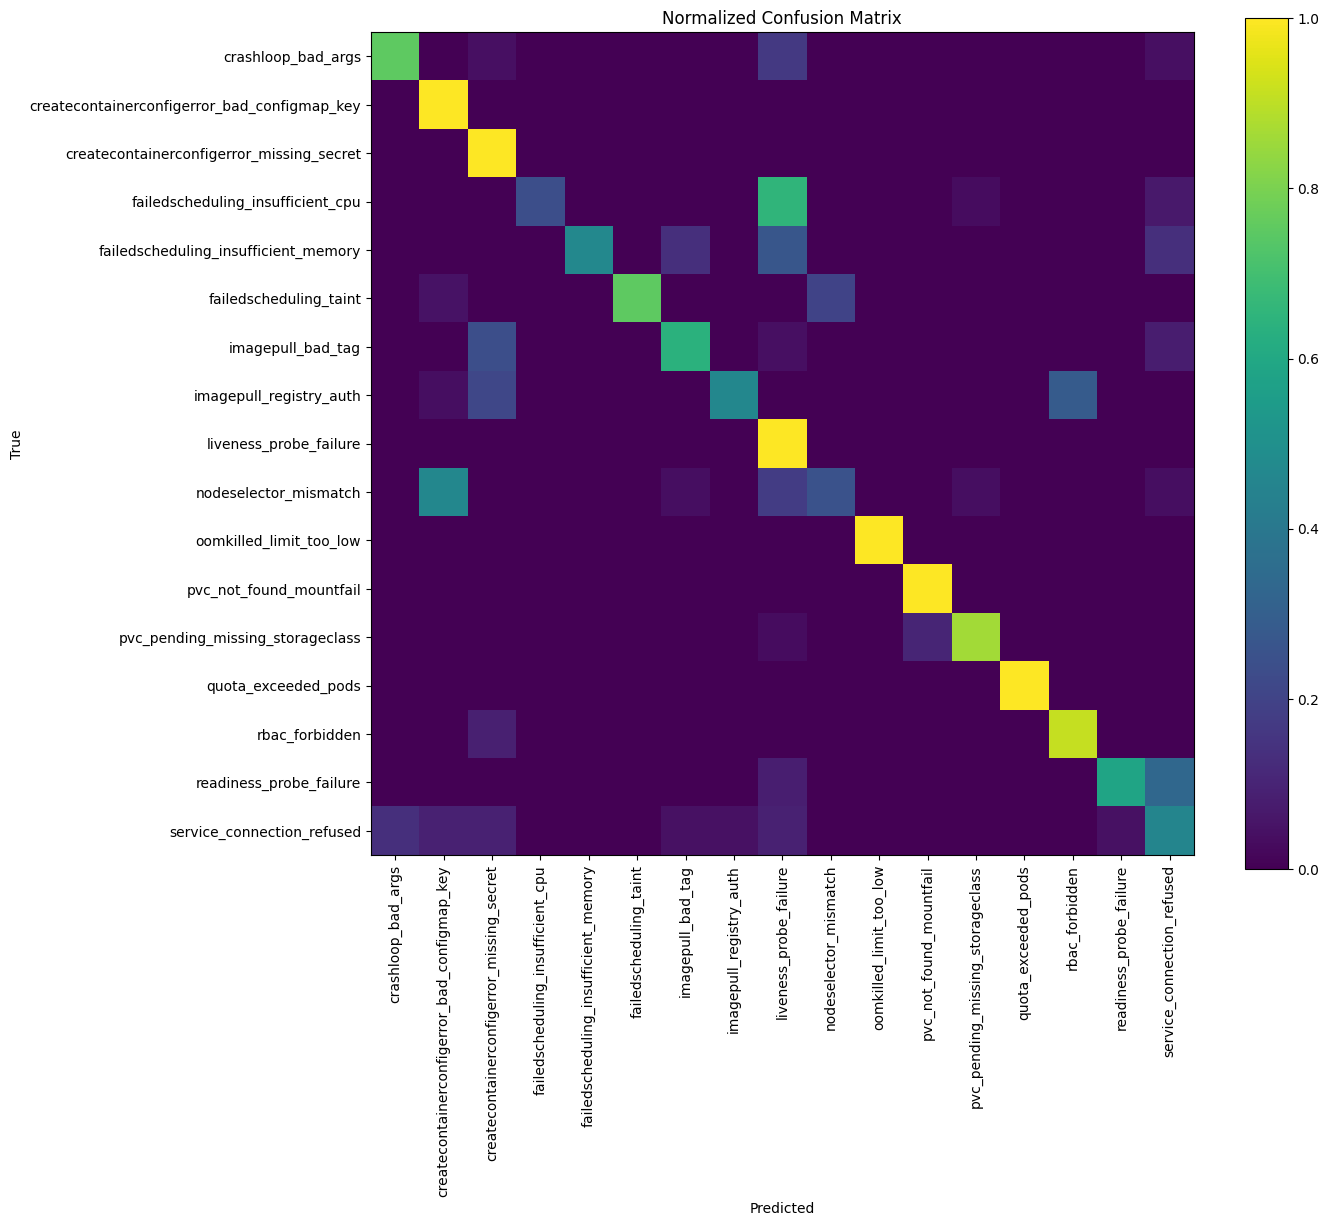

In [29]:
plt.figure(figsize=(14, 12))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("Normalized Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.tight_layout()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [30]:
confusions = []

for i, true_lbl in enumerate(labels):
    for j, pred_lbl in enumerate(labels):
        if i != j and cm[i, j] > 0:
            confusions.append({
                "true_scenario": true_lbl,
                "pred_scenario": pred_lbl,
                "count": int(cm[i, j]),
            })

confusions_df = pd.DataFrame(confusions).sort_values("count", ascending=False)
confusions_df.head(30)

,true_scenario,pred_scenario,count
3,failedscheduling_insufficient_cpu,liveness_probe_failure,19
17,nodeselector_mismatch,createcontainerconfigerror_bad_configmap_key,13
16,imagepull_registry_auth,rbac_forbidden,8
26,readiness_probe_failure,service_connection_refused,8
15,imagepull_registry_auth,createcontainerconfigerror_missing_secret,6
11,imagepull_bad_tag,createcontainerconfigerror_missing_secret,6
19,nodeselector_mismatch,liveness_probe_failure,5
1,crashloop_bad_args,liveness_probe_failure,4
10,failedscheduling_taint,nodeselector_mismatch,4
7,failedscheduling_insufficient_memory,liveness_probe_failure,4


In [31]:
ACTION_PATTERNS = {
    "patch_resource": [
        r"\bpatch\b",
        r"\bedit\b",
        r"\bset resources\b",
    ],
    "restart_rollout": [
        r"rollout restart",
        r"\brestart\b",
        r"\brecreate\b",
    ],
    "get_pods": [
        r"kubectl .* get pods?\b",
        r"\bget pods?\b",
    ],
    "describe_pod": [
        r"kubectl .* describe pod\b",
        r"\bdescribe pod\b",
    ],
    "get_events": [
        r"kubectl .* get events\b",
        r"\bget events\b",
    ],
    "check_secret": [
        r"get secret",
        r"\bsecret\b",
    ],
    "create_secret": [
        r"create secret",
        r"apply .*secret",
    ],
    "check_configmap": [
        r"get configmap",
        r"\bconfigmap\b",
    ],
    "check_pvc": [
        r"get pvc",
        r"describe pvc",
        r"persistentvolumeclaim",
    ],
    "check_storageclass": [
        r"get storageclass",
        r"\bstorageclass\b",
    ],
    "describe_node": [
        r"describe node",
        r"get nodes",
        r"\bnode selector\b",
        r"\btaint\b",
        r"\btoleration\b",
    ],
    "check_rbac": [
        r"can-i",
        r"\brbac\b",
        r"\bforbidden\b",
        r"\bserviceaccount\b",
        r"\brole(binding)?\b",
    ],
    "check_probe": [
        r"readiness probe",
        r"liveness probe",
        r"\bprobe\b",
    ],
    "check_image_pull": [
        r"imagepullbackoff",
        r"errimagepull",
        r"pull access denied",
        r"manifest unknown",
        r"\bimage\b",
    ],
}

In [32]:
def normalize_text_simple(text):
    return str(text).lower().strip()

def extract_action_types(text):
    text = normalize_text_simple(text)
    matched = set()

    for action_type, patterns in ACTION_PATTERNS.items():
        for pat in patterns:
            if re.search(pat, text):
                matched.add(action_type)
                break

    return matched

def action_type_recall(pred_text, gt_text):
    pred_actions = extract_action_types(pred_text)
    gt_actions = extract_action_types(gt_text)

    if not gt_actions:
        return 1.0 if not pred_actions else 0.0

    return len(pred_actions & gt_actions) / len(gt_actions)

def action_type_precision(pred_text, gt_text):
    pred_actions = extract_action_types(pred_text)
    gt_actions = extract_action_types(gt_text)

    if not pred_actions:
        return 1.0 if not gt_actions else 0.0

    return len(pred_actions & gt_actions) / len(pred_actions)

def action_type_f1(pred_text, gt_text):
    p = action_type_precision(pred_text, gt_text)
    r = action_type_recall(pred_text, gt_text)
    if p + r == 0:
        return 0.0
    return 2 * p * r / (p + r)

In [33]:
res_df["action_type_precision"] = res_df.apply(
    lambda x: action_type_precision(x["prediction"], x["ground_truth"]), axis=1
)
res_df["action_type_recall"] = res_df.apply(
    lambda x: action_type_recall(x["prediction"], x["ground_truth"]), axis=1
)
res_df["action_type_f1"] = res_df.apply(
    lambda x: action_type_f1(x["prediction"], x["ground_truth"]), axis=1
)

print("Action Type Precision mean:", res_df["action_type_precision"].mean())
print("Action Type Recall mean:", res_df["action_type_recall"].mean())
print("Action Type F1 mean:", res_df["action_type_f1"].mean())

Action Type Precision mean: 0.7271666666666667
Action Type Recall mean: 0.7274523809523811
Action Type F1 mean: 0.6914929931179931


In [34]:
VERIFICATION_HINTS = [
    r"\bverify\b",
    r"\bvalidation\b",
    r"\bready\b",
    r"\brunning\b",
    r"\bget pods?\b",
    r"\bdescribe pod\b",
    r"\bget events\b",
    r"\bno longer\b",
    r"\bevents stop\b",
    r"\bconfirm\b",
]

def verification_completeness_score(pred_text):
    text = normalize_text_simple(pred_text)

    has_verification_section = "verification" in text
    matched_hints = sum(1 for pat in VERIFICATION_HINTS if re.search(pat, text))

    # normalize to 0..1
    hint_score = min(matched_hints / 4.0, 1.0)

    if has_verification_section:
        return min(0.5 + 0.5 * hint_score, 1.0)
    return 0.5 * hint_score

In [35]:
res_df["verification_completeness"] = res_df["prediction"].apply(verification_completeness_score)

print("Verification Completeness mean:", res_df["verification_completeness"].mean())

Verification Completeness mean: 0.8890625


In [36]:
res_df.groupby("scenario_id")[["verification_completeness"]].mean().sort_values("verification_completeness")

,verification_completeness
scenario_id,
failedscheduling_taint,0.775000
service_connection_refused,0.840909
rbac_forbidden,0.858696
quota_exceeded_pods,0.861111
nodeselector_mismatch,0.861607
oomkilled_limit_too_low,0.875000
readiness_probe_failure,0.880208
liveness_probe_failure,0.880682
pvc_not_found_mountfail,0.880682


In [37]:
res_df["prediction_chars"] = res_df["prediction"].astype(str).apply(len)
res_df["ground_truth_chars"] = res_df["ground_truth"].astype(str).apply(len)

res_df["prediction_words"] = res_df["prediction"].astype(str).apply(lambda s: len(s.split()))
res_df["ground_truth_words"] = res_df["ground_truth"].astype(str).apply(lambda s: len(s.split()))

print("Prediction chars mean:", res_df["prediction_chars"].mean())
print("Ground truth chars mean:", res_df["ground_truth_chars"].mean())
print("Prediction words mean:", res_df["prediction_words"].mean())
print("Ground truth words mean:", res_df["ground_truth_words"].mean())

Prediction chars mean: 1187.1475
Ground truth chars mean: 765.5725
Prediction words mean: 156.0625
Ground truth words mean: 103.265


In [38]:
res_df["prediction_tokens"] = res_df["prediction"].apply(lambda s: len(tokenizer(str(s))["input_ids"]))
res_df["ground_truth_tokens"] = res_df["ground_truth"].apply(lambda s: len(tokenizer(str(s))["input_ids"]))

print("Prediction tokens mean:", res_df["prediction_tokens"].mean())
print("Ground truth tokens mean:", res_df["ground_truth_tokens"].mean())

Prediction tokens mean: 318.8075
Ground truth tokens mean: 180.6825


In [42]:
import time
from tqdm.auto import tqdm

# evaluate on only 400 rows max
n_eval = min(400, len(test_df))
eval_df = test_df.sample(n=n_eval, random_state=42).reset_index(drop=True)

results = []

print("Total rows being evaluated:", len(eval_df))

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Evaluating"):
    start = time.time()
    pred = generate_response(model, tokenizer, row)
    elapsed = time.time() - start

    gt = build_target_response(row)

    pred_scenario = predict_scenario_from_text(pred)
    scenario_match = int(pred_scenario == row["scenario_id"])

    result = {
        "row_idx": idx,
        "scenario_id": row["scenario_id"],
        "pred_scenario": pred_scenario,
        "scenario_match": scenario_match,
        "section_score": section_presence_score(pred),
        "keyword_recall": keyword_recall(pred, gt),
        "command_recall": command_recall(pred, gt),
        "ground_truth": gt,
        "prediction": pred,
        "latency_sec": elapsed,
    }
    results.append(result)

res_df = pd.DataFrame(results)
print("Done. Rows evaluated:", len(res_df))

Total rows being evaluated: 400


Evaluating:   0%|          | 0/400 [00:00<?, ?it/s]

Done. Rows evaluated: 400


In [43]:
print("Latency mean:", res_df["latency_sec"].mean())
print("Latency median:", res_df["latency_sec"].median())
print("Latency p95:", res_df["latency_sec"].quantile(0.95))

Latency mean: 12.372907017469407
Latency median: 12.405829310417175
Latency p95: 16.514256227016446


In [45]:
extra_summary = {
    "overall_accuracy": float(overall_accuracy),
    "macro_precision": float(macro_p),
    "macro_recall": float(macro_r),
    "macro_f1": float(macro_f1),
    "weighted_precision": float(weighted_p),
    "weighted_recall": float(weighted_r),
    "weighted_f1": float(weighted_f1),
}

if "action_type_precision" in res_df.columns:
    extra_summary["action_type_precision_mean"] = float(res_df["action_type_precision"].mean())

if "action_type_recall" in res_df.columns:
    extra_summary["action_type_recall_mean"] = float(res_df["action_type_recall"].mean())

if "action_type_f1" in res_df.columns:
    extra_summary["action_type_f1_mean"] = float(res_df["action_type_f1"].mean())

if "verification_completeness" in res_df.columns:
    extra_summary["verification_completeness_mean"] = float(res_df["verification_completeness"].mean())

if "prediction_words" in res_df.columns:
    extra_summary["prediction_words_mean"] = float(res_df["prediction_words"].mean())

if "ground_truth_words" in res_df.columns:
    extra_summary["ground_truth_words_mean"] = float(res_df["ground_truth_words"].mean())

pd.Series(extra_summary)

overall_accuracy      0.715000
macro_precision       0.800324
macro_recall          0.727960
macro_f1              0.714964
weighted_precision    0.798290
weighted_recall       0.715000
weighted_f1           0.705148
dtype: float64

In [46]:
print(res_df.head().to_string())
print(res_df.columns.tolist())

   row_idx                        scenario_id            pred_scenario  scenario_match  section_score  keyword_recall  command_recall                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           ground_truth                                                                                            